Este notebook presenta una simulación del sistema de rating Elo, comúnmente utilizado en ajedrez y otros deportes electrónicos para calcular la habilidad relativa de los jugadores. El sistema Elo ajusta los ratings de los jugadores después de cada partida basándose en el resultado real de la partida y el resultado esperado, el cual se calcula a partir de los ratings pre-partida de los jugadores.

El objetivo de esta simulación es demostrar cómo evolucionan los ratings Elo de un conjunto de jugadores a lo largo de una serie de partidas simuladas. Utilizamos las siguientes fórmulas clave en nuestra simulación:

Fórmula para el Resultado Esperado ($E_A$ y $E_B$):

La probabilidad de que el jugador A gane contra el jugador B se calcula utilizando la siguiente fórmula:
$$ E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}} $$
De manera similar, la probabilidad de que el jugador B gane contra el jugador A es:
$$ E_B = \frac{1}{1 + 10^{(R_A - R_B)/400}} $$
Donde $R_A$ y $R_B$ son los ratings Elo actuales de los jugadores A y B, respectivamente.

Fórmula para la Actualización del Rating Elo ($R'_A$ y $R'_B$):

Después de una partida, los nuevos ratings Elo se calculan de la siguiente manera:
$$ R'_A = R_A + K \cdot (S_A - E_A) $$
$$ R'_B = R_B + K \cdot (S_B - E_B) $$
Donde:
$R'_A$ y $R'_B$ son los nuevos ratings Elo de los jugadores A y B. $K$ es el factor K, una constante que determina la intensidad de los ajustes en el rating. Un factor K más alto significa que los cambios en el rating son más drásticos después de cada partida. En nuestra simulación, utilizamos $K=16$ para jugadores considerados Grand Masters. $S_A$ y $S_B$ son los resultados reales de la partida para los jugadores A y B. En nuestro sistema, $S_A = 1$ si A gana y $S_A = 0$ si A pierde. Similarmente para $S_B$.


En este notebook, simulamos partidas basándonos en las tasas de victorias predefinidas de los jugadores y aplicamos estas fórmulas para rastrear la evolución de sus ratings Elo a lo largo de múltiples rondas de juego.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
def expected_points(R_A, R_B):
  E_A = 1 / (1 + 10 ** ((R_B - R_A) / 400))
  E_B = 1 / (1 + 10 ** ((R_A - R_B) / 400))
  return E_A, E_B

In [9]:
def simulated_points(WR_A, WR_B):
  total_WR = WR_A + WR_B
  prob_A_wins = WR_A / total_WR
  if np.random.rand() < prob_A_wins:
    return 1, 0  # Player A wins
  else:
    return 0, 1  # Player B wins

In [10]:
def new_elo(R_A, R_B, E_A, E_B, S_A, S_B, K=16): # K = 16 because they are Grand Masters, if not, K = 32
  R_A_new = R_A + K * (S_A - E_A)
  R_B_new = R_B + K * (S_B - E_B)
  return R_A_new, R_B_new

In [11]:
data = {'player': ['Magnus Carlsen', 'Hikaru Nakamura', 'Fabiano Caruana', 'MVL', 'Levon Aronian', 'Hans Niemann', 'Wesley So', 'Alireza Firouzja'],
        'winning_rate': [0.8, 0.7, 0.7, 0.6, 0.6, 0.5, 0.4, 0.4],
        'elo_match_0': [2839, 2807, 2784, 2736, 2737, 2735, 2745, 2766]}


df_original = pd.DataFrame(data)
display(df_original)

,player,winning_rate,elo_match_0
0,Magnus Carlsen,0.8,2839
1,Hikaru Nakamura,0.7,2807
2,Fabiano Caruana,0.7,2784
3,MVL,0.6,2736
4,Levon Aronian,0.6,2737
5,Hans Niemann,0.5,2735
6,Wesley So,0.4,2745
7,Alireza Firouzja,0.4,2766


Enter the number of matchs: 80


,player,winning_rate,elo_match_0,elo_match_1,elo_match_2,elo_match_3,elo_match_4,elo_match_5,elo_match_6,elo_match_7,elo_match_8,elo_match_9,elo_match_10,elo_match_11,elo_match_12,elo_match_13,elo_match_14,elo_match_15,elo_match_16,elo_match_17,elo_match_18,elo_match_19,elo_match_20,elo_match_21,elo_match_22,elo_match_23,elo_match_24,elo_match_25,elo_match_26,elo_match_27,elo_match_28,elo_match_29,elo_match_30,elo_match_31,elo_match_32,elo_match_33,elo_match_34,elo_match_35,elo_match_36,elo_match_37,elo_match_38,elo_match_39,elo_match_40,elo_match_41,elo_match_42,elo_match_43,elo_match_44,elo_match_45,elo_match_46,elo_match_47,elo_match_48,elo_match_49,elo_match_50,elo_match_51,elo_match_52,elo_match_53,elo_match_54,elo_match_55,elo_match_56,elo_match_57,elo_match_58,elo_match_59,elo_match_60,elo_match_61,elo_match_62,elo_match_63,elo_match_64,elo_match_65,elo_match_66,elo_match_67,elo_match_68,elo_match_69,elo_match_70,elo_match_71,elo_match_72,elo_match_73,elo_match_74,elo_match_75,elo_match_76,elo_match_77,elo_match_78,elo_match_79,elo_match_80
0,Magnus Carlsen,0.8,2839.0,2845.3,2835.7,2842.5,2833.2,2824.3,2815.8,2807.2,2814.9,2806.3,2814.0,2805.3,2813.0,2804.2,2811.5,2818.7,2826.0,2833.2,2840.4,2831.2,2838.0,2844.9,2851.7,2858.5,2849.3,2856.0,2846.4,2852.8,2859.2,2865.6,2856.0,2862.8,2869.2,2859.3,2865.7,2872.1,2878.1,2868.2,2874.3,2880.0,2885.5,2890.9,2896.5,2902.0,2907.6,2913.2,2902.4,2908.0,2897.3,2903.0,2908.7,2914.4,2919.7,2925.1,2930.1,2935.2,2940.3,2945.4,2950.2,2939.1,2944.3,2933.1,2922.0,2910.9,2915.9,2920.9,2925.6,2930.4,2919.2,2924.3,2913.5,2919.1,2908.3,2913.9,2903.5,2909.4,2915.3,2920.9,2926.1,2931.0,2935.7
1,Hikaru Nakamura,0.7,2807.0,2798.1,2805.5,2796.9,2788.7,2796.8,2788.9,2780.9,2773.3,2765.6,2774.3,2782.5,2790.7,2798.4,2789.8,2797.6,2805.3,2813.0,2820.7,2827.9,2834.8,2841.7,2848.6,2855.5,2862.3,2868.8,2874.9,2880.7,2886.5,2876.3,2882.5,2888.7,2878.5,2884.4,2890.2,2896.1,2885.6,2891.5,2897.1,2886.4,2875.7,2881.4,2887.1,2892.9,2882.6,2872.7,2878.8,2885.0,2874.8,2880.9,2871.0,2861.5,2868.0,2874.5,2880.6,2886.7,2892.8,2899.0,2904.7,2894.5,2900.6,2890.3,2896.1,2901.5,2906.7,2911.8,2900.7,2890.0,2895.6,2901.3,2907.0,2896.7,2886.3,2892.4,2898.4,2888.4,2894.8,2884.8,2890.8,2880.5,2886.1
2,Fabiano Caruana,0.7,2784.0,2791.6,2783.2,2775.1,2783.4,2791.6,2783.8,2776.0,2784.5,2792.5,2800.5,2808.2,2799.8,2807.3,2814.5,2805.7,2813.2,2820.8,2812.2,2819.7,2826.8,2817.9,2809.3,2817.0,2824.8,2816.1,2823.4,2830.3,2837.2,2844.1,2851.0,2857.9,2848.4,2854.9,2845.4,2852.3,2842.8,2849.6,2840.1,2846.6,2852.7,2858.9,2865.1,2871.3,2861.6,2868.1,2874.4,2864.6,2870.8,2877.0,2883.3,2889.5,2895.4,2901.2,2890.8,2896.7,2886.6,2892.8,2882.7,2889.0,2895.2,2901.1,2890.6,2896.1,2901.4,2906.7,2895.7,2885.0,2874.8,2880.9,2887.0,2877.1,2883.2,2889.3,2895.4,2885.5,2891.9,2898.0,2903.7,2909.1,2898.2
3,MVL,0.6,2736.0,2744.7,2737.4,2746.3,2739.3,2732.5,2726.1,2735.5,2744.9,2753.9,2746.8,2739.7,2732.8,2725.9,2735.0,2728.0,2721.3,2730.9,2724.4,2717.9,2711.3,2721.0,2730.6,2740.2,2749.7,2758.7,2767.3,2775.5,2783.7,2775.8,2784.3,2792.7,2800.7,2808.3,2815.8,2823.4,2814.5,2822.0,2829.1,2819.8,2810.6,2817.7,2808.8,2800.3,2808.1,2799.9,2807.7,2815.4,2822.8,2830.1,2837.3,2844.6,2851.5,2858.3,2848.8,2839.6,2830.8,2822.3,2829.7,2821.2,2828.9,2836.3,2827.2,2818.1,2809.1,2816.4,2823.3,2830.3,2837.2,2828.1,2819.4,2811.0,2818.6,2810.2,2818.1,2825.9,2833.7,2841.1,2832.0,2823.0,2829.9
4,Levon Aronian,0.6,2737.0,2729.7,2722.7,2732.0,2725.3,2718.8,2728.7,2722.1,2715.8,2725.4,2734.9,2728.0,2737.5,2746.5,2739.0,2748.0,2740.8,2750.0,2743.1,2752.2,2760.8,2753.4,2746.3,2755.5,2764.6,2757.3,2750.0,2758.6,2767.1,2775.6,2768.1,2776.9,2769.2,2761.5,2770.2,2778.8,2786.9,2795.1,2802.8,2794.1,2785.4,2793.1,2784.8,2776.9,2769.2,2761.9,2770.6,2763.1,2755.7,2748.5,2757.7,2750.7,2743.7,2753.1,2745.9,2755.1,2748.2,2757.6,2750.5,2759.8,2768.9,2761.7,2754.3,2762.9,2771.1,2763.3,2755.4,2747.9,2756.8,2749.6,2742.6,2752.0,2761.0,2769.8,2762.7,2771.8,2780.8,2789.4,2797.5,2805.3,2812.6
5,Hans

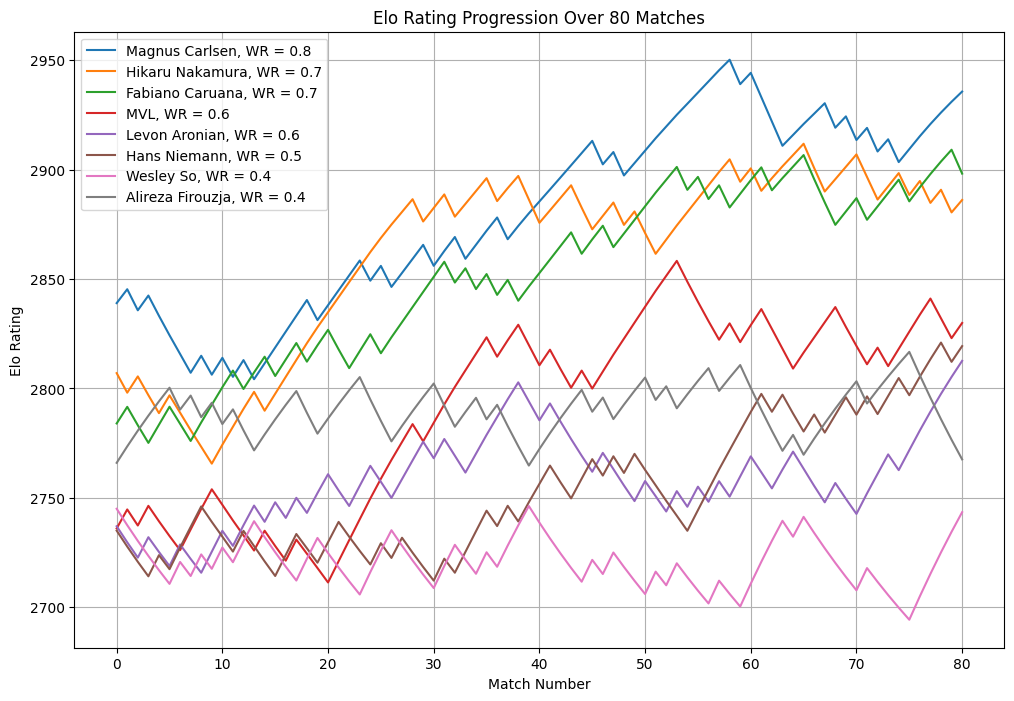

In [12]:
df = df_original.copy()

N = int(input('Enter the number of matchs: '))

num_players = len(df)

for n in range(1, N + 1):
  for i in range(num_players):
      for j in range(i + 1, num_players):
          player_a_data = df.iloc[i]
          player_b_data = df.iloc[j]

          R_A = player_a_data[f'elo_match_{n-1}']
          WR_A = player_a_data['winning_rate']

          R_B = player_b_data[f'elo_match_{n-1}']
          WR_B = player_b_data['winning_rate']

          E_A, E_B = expected_points(R_A, R_B)
          S_A, S_B = simulated_points(WR_A, WR_B)

          R_A_new, R_B_new = new_elo(R_A, R_B, E_A, E_B, S_A, S_B)

          df.loc[i, f'elo_match_{n}'] = R_A_new
          df.loc[j, f'elo_match_{n}'] = R_B_new

cols_to_format = df.columns[1:]
display(df.style.format({col: '{:.1f}' for col in cols_to_format}))

fig, axes = plt.subplots(figsize=(12, 8))

elo_columns = [col for col in df.columns if 'elo_match' in col]

for i in range(num_players):
  player_data = df.iloc[i]
  player_name = player_data['player']
  player_winning_rate = player_data['winning_rate']
  elo_values = player_data[elo_columns].values
  plt.plot(range(0, N+1), elo_values, label=f'{player_name}, WR = {player_winning_rate}')

plt.xlabel('Match Number')
plt.ylabel('Elo Rating')
plt.title(f'Elo Rating Progression Over {N} Matches')
plt.legend()
plt.grid(True)
plt.show()